# Практическая работа №5

**Цель работы:** изучить и сравнить методы градиентного бустинга для задачи бинарной классификации на обработанном датасете. Провести автоматический подбор гиперпараметров и сравнить результаты с базовыми настройками.


**Задачи работы:**

1. Провести анализ и предобработку данных.
2. Реализовать и обучить классический Gradient Boosting.
3. Реализовать и обучить две вариации градиентного бустинга (XGBoost и LightGBM).
4. Подобрать гиперпараметры моделей с помощью Optuna.
5. Оценить модели по выбранным метрикам качества.
6. Сравнить результаты алгоритмов между собой, а также без и с использованием Optuna.
7. Построить графики обучения целевой функции.

**Используемые алгоритмы:**

1. **Gradient Boosting:** классический градиентный бустинг строит ансамбль слабых моделей (обычно неглубоких деревьев), обучая каждую следующую модель на ошибках предыдущих. На каждой итерации минимизируется функция потерь (лог-лосс для классификации) при помощи градиентного спуска в пространстве функций. Отличается стабильной сходимостью и интерпретируемостью, но медленный на больших данных. Ключевые гиперпараметры: `n_estimators` число итераций/деревьев,`learning_rate` скорость обучения (уменьшает вклад каждого нового дерева), `max_depth`, `min_samples_leaf` контролируют сложность отдельных деревьев, `subsample` доля обучающего множества для стохастического бустинга (уменьшает переобучение).
2. **XGBoost:** эффективная и популярная реализация градиентного бустинга с оптимизациями по скорости и памяти. Добавляет регуляризацию, поддержку бустинга по деревьям с сокращёнными вычислениями, продвинутые алгоритмы построения деревьев и возможность параллельной или распределённой тренировки.
Ключевые параметры: `eta` скорость обучения, `max_depth`, `subsample`, `colsample_bytree`, `lambda`/`alpha` регуляризация, `n_estimators`.
3. **LightGBM:** реализация бустинга, ориентированная на очень быстрый рост деревьев по листьям с ограничением по максимальной глубине, что даёт высокую точность при меньшем числе итераций. Поддерживает эффективную обработку категориальных признаков (без явного one-hot) и оптимизации памяти.
Ключевые параметры: `num_leaves`, `learning_rate`, `max_depth`, `feature_fraction`, `bagging_fraction`, `min_data_in_leaf`.
3. **Optuna:** библиотека для автоматического подбора гиперпараметров с использованием методов оптимизации на основе истории предыдущих экспериментов. Итеративно выбирает комбинации параметров, обучает модель и оценивает качество, стремясь минимизировать или максимизировать заданную метрику.

**Основные метрики:**

- **F1-score** для класса «дождь» — основная метрика, так как классы несбалансированы. Учитывает и precision, и recall.  
- **Accuracy** — общая оценка, но второстепенная при дисбалансе.

Датасет (из 1 работы): https://www.kaggle.com/datasets/jsphyg/weather-dataset-rattle-package/data

In [ ]:
# Используемые библиотеки
!pip install optuna
!pip install lightgbm -q
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import optuna
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
from xgboost import XGBClassifier
import lightgbm as lgb


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.9/400.9 kB 6.2 MB/s eta 0:00:00


## 1. Загрузка и анализ данных

Ранее для данного датасета Rain in Australia была проведена полная предобработка данных: обработаны пропуски, удалены выбросы, категориальные признаки преобразованы с помощью One-Hot Encoding, удалены ненужные и сильно коррелированные признаки, дата преобразована в числовой формат. Данные разделены на обучающую (train), валидационную (valid) и тестовую (test) выборки.

Для моделей на основе деревьев важно, чтобы данные были чистыми и не содержали пропусков, что уже обеспечено на предыдущих этапах. Таким образом, на данном этапе можно сразу загрузить подготовленные данные и перейти к обучению моделей.

,Rainfall,Sunshine,WindGustSpeed,Humidity9am,Humidity3pm,Pressure9am,Cloud3pm,Temp3pm,RainToday,Location_Albany,...,Location_WaggaWagga,Location_Walpole,Location_Watsonia,Location_Williamtown,Location_Witchcliffe,Location_Wollongong,Location_Woomera,Year,Month,Day
10832,2.540517,-2.830020,0.769071,1.221947,0.511072,0.926395,1.028669,-0.780448,1,False,...,False,False,False,False,False,False,False,2011,6,13
64426,5.047411,0.173575,1.301877,0.272726,0.024543,-1.297080,0.719060,-0.083081,1,False,...,False,False,False,False,False,False,False,2017,1,17
61488,-0.279738,1.850000,0.236264,-1.098371,-0.559292,-0.911678,-0.828984,0.730514,0,False,...,False,False,False,False,False,False,False,2015,1,1
81810,-0.279738,-0.769414,0.084034,0.483664,1.484131,0.600286,1.028669,-1.448758,0,False,...,False,False,False,False,False,False,False,2013,6,16
70346,0.612137,-0.420159,-0.068197,1.274681,1.143560,0.363115,0.099843,-0.649691,1,False,...,False,False,False,False,False,False,False,2012,8,4


,RainTomorrow
10832,1
64426,1
61488,0
81810,1
70346,1


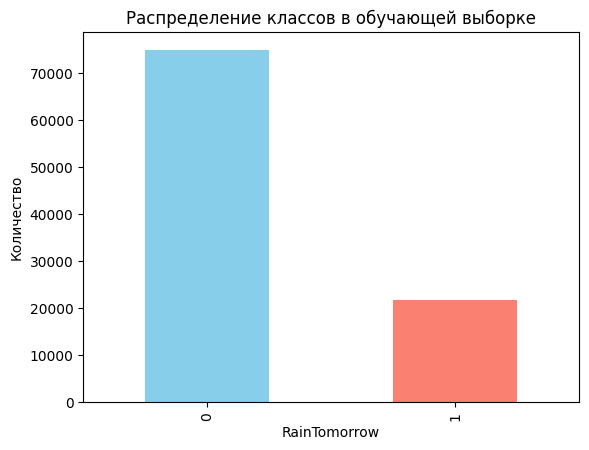

In [ ]:
# Загрузка обработанных данных
!wget -q https://github.com/GusevaVarvara/Weather-dataset/raw/main/train_reduced.pkl
!wget -q https://github.com/GusevaVarvara/Weather-dataset/raw/main/val_reduced.pkl
!wget -q https://github.com/GusevaVarvara/Weather-dataset/raw/main/test_reduced.pkl

X_train, y_train = joblib.load("train_reduced.pkl")
X_val, y_val = joblib.load("val_reduced.pkl")
X_test, y_test = joblib.load("test_reduced.pkl")

# Проверим данные
display(X_train.head())
display(y_train.head())

# Распределение целевого признака
pd.Series(y_train).value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title("Распределение классов в обучающей выборке")
plt.xlabel("RainTomorrow")
plt.ylabel("Количество")
plt.show()

Видно, что наблюдается дисбаланс классов, поэтому при оценке качества моделей важно учитывать не только Accuracy, но и F1-score.


## 2. Gradient Boosting

Обучим классическую модель Gradient Boosting. В качестве графика обучения целевой функции построим график изменения функции потерь (log-loss), а также для наглядности можно построить график динамики F1-метрики при добавлении каждого нового дерева.


Validation Accuracy (Gradient Boosting): 0.8452405576469615
Validation F1-score (Gradient Boosting): 0.5855766035227651

Classification report (validation):
              precision    recall  f1-score   support

           0     0.8650    0.9485    0.9049     18754
           1     0.7325    0.4877    0.5856      5419

    accuracy                         0.8452     24173
   macro avg     0.7988    0.7181    0.7452     24173
weighted avg     0.8353    0.8452    0.8333     24173


Test Accuracy (Gradient Boosting): 0.8487505274508884
Test F1-score (Gradient Boosting): 0.592058674759737

Classification report (test):
              precision    recall  f1-score   support

           0     0.8659    0.9525    0.9072     16548
           1     0.7486    0.4896    0.5921      4781

    accuracy                         0.8488     21329
   macro avg     0.8073    0.7211    0.7496     21329
weighted avg     0.8397    0.8488    0.8365     21329



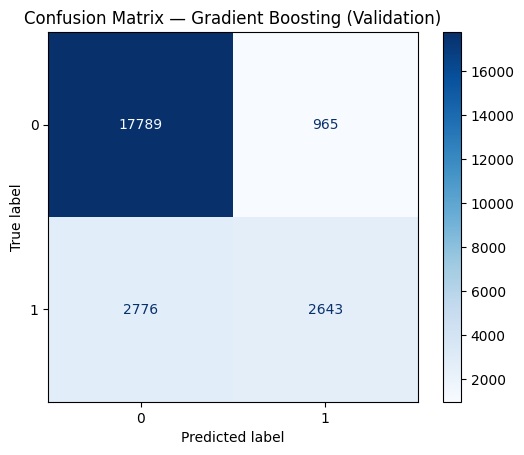

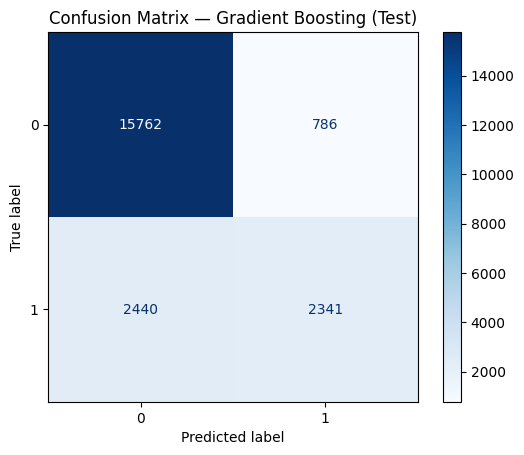

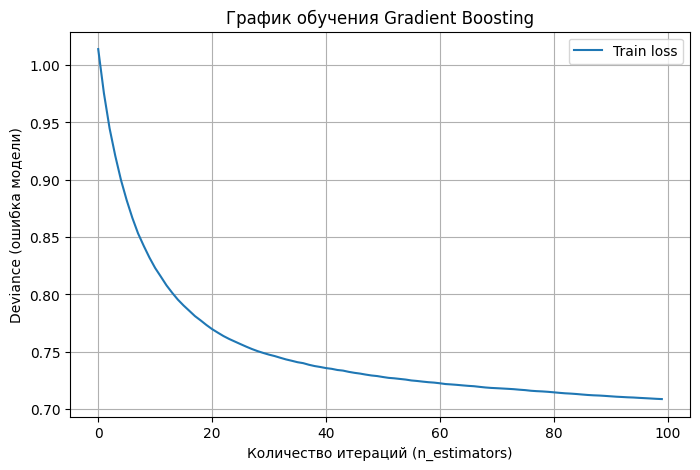

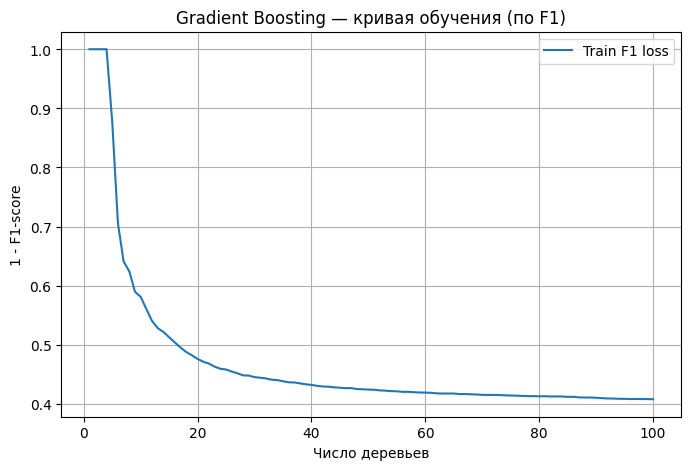

In [ ]:
# Инициализация Gradient Boosting
gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# Обучение модели
gb.fit(X_train, y_train)
y_val_pred = gb.predict(X_val)
y_test_pred = gb.predict(X_test)

# Метрики
val_acc = accuracy_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred)
test_acc = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

print("Validation Accuracy (Gradient Boosting):", val_acc)
print("Validation F1-score (Gradient Boosting):", val_f1)
print("\nClassification report (validation):")
print(classification_report(y_val, y_val_pred, digits=4))

print("\nTest Accuracy (Gradient Boosting):", test_acc)
print("Test F1-score (Gradient Boosting):", test_f1)
print("\nClassification report (test):")
print(classification_report(y_test, y_test_pred, digits=4))

# Матрица ошибок
ConfusionMatrixDisplay.from_estimator(gb, X_val, y_val, cmap="Blues")
plt.title("Confusion Matrix — Gradient Boosting (Validation)")
plt.show()
ConfusionMatrixDisplay.from_estimator(gb, X_test, y_test, cmap="Blues")
plt.title("Confusion Matrix — Gradient Boosting (Test)")
plt.show()

# Построим график изменения функции потерь (stage-wise)
plt.figure(figsize=(8, 5))
plt.plot(gb.train_score_, label="Train loss")
plt.xlabel("Количество итераций (n_estimators)")
plt.ylabel("Deviance (ошибка модели)")
plt.title("График обучения Gradient Boosting")
plt.legend()
plt.grid(True)
plt.show()

# Кривая обучения (по ошибке на каждой итерации)
n_estimators = gb.n_estimators_
train_loss = np.zeros(n_estimators)
for i, y_pred in enumerate(gb.staged_predict(X_train)):
    train_loss[i] = 1 - f1_score(y_train, y_pred)

plt.figure(figsize=(8,5))
plt.plot(range(1, n_estimators+1), train_loss, label="Train F1 loss")
plt.title("Gradient Boosting — кривая обучения (по F1)")
plt.xlabel("Число деревьев")
plt.ylabel("1 - F1-score")
plt.legend()
plt.grid(True)
plt.show()

Точность на обучающей и тестовой выборках практически совпадает, что говорит об отсутствии выраженного переобучения и стабильности модели на новых данных.

Как и в предыдущих моделях (Decision Tree, Random Forest), наблюдается дисбаланс классов: модель лучше предсказывает отсутствие дождя (класс 0), чем его наличие (класс 1). Для класса 1 precision около 0.75, а recall около 0.49, модель находит чуть меньше половины реальных случаев дождя. Это отражается в сравнительно невысоком F1-значении = 0.59.

Тем не менее, показатели F1-score улучшились по сравнению с Decision Tree (0.52) и близки к результатам Random Forest (0.61). Это подтверждает, что Gradient Boosting способен более точно улавливать сложные закономерности, но требует тонкой настройки гиперпараметров.

На графике целевой функции (log-loss) видно, что ошибка постепенно уменьшается, что говорит о сходимости модели. Для наглядности также показана динамика F1-score, которая отражает улучшение качества классификации по мере добавления деревьев. В начале модель быстро обучается на наиболее сильных закономерностях, а затем улучшения становятся постепенными.


## 3. XGBoost



Обучим усовершенствованный вариант классического градиентного бустинга XGBoost. В XGBoost специально предусмотрена возможность мониторинга потерь на каждом бустинге, поэтому удобно построить график обучения целевой функции, то есть как менялась логарифмическая потеря на train и validation при обучении.

Validation Accuracy (XGBoost): 0.8535556199065073
Validation F1-score (XGBoost): 0.6177931332325631

Classification report (validation):
               precision    recall  f1-score   support

           0       0.87      0.95      0.91     18754
           1       0.74      0.53      0.62      5419

    accuracy                           0.85     24173
   macro avg       0.81      0.74      0.76     24173
weighted avg       0.85      0.85      0.84     24173


Test Accuracy (XGBoost): 0.8575648178536265
Test F1-score (XGBoost): 0.6248456408989874

Classification report (test):
               precision    recall  f1-score   support

           0       0.88      0.95      0.91     16548
           1       0.76      0.53      0.62      4781

    accuracy                           0.86     21329
   macro avg       0.82      0.74      0.77     21329
weighted avg       0.85      0.86      0.85     21329



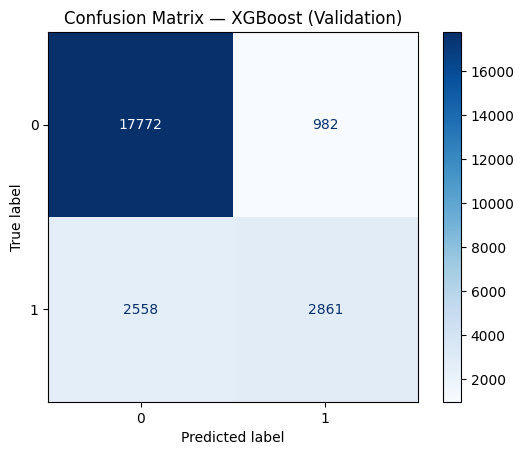

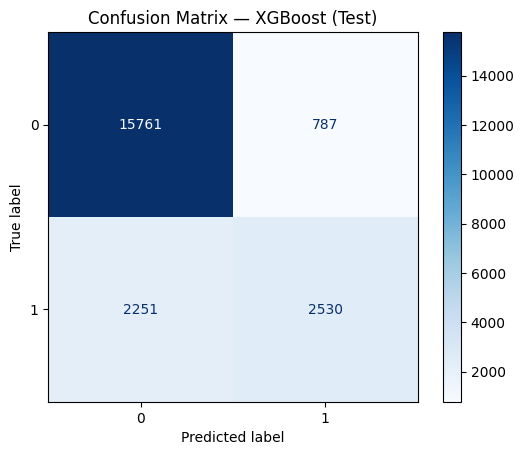

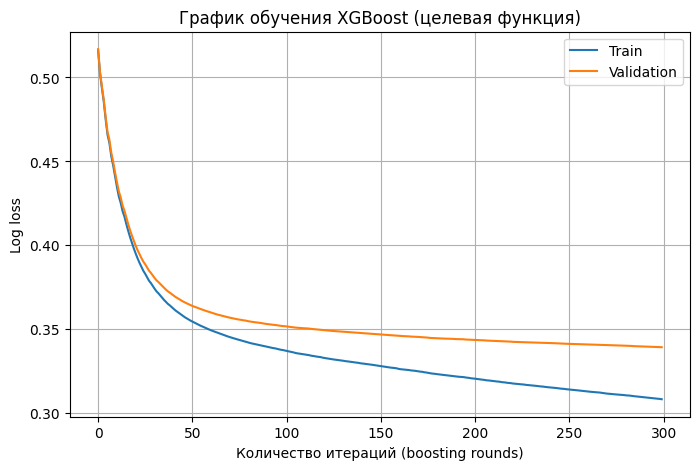

In [ ]:
# Инициализация модели XGBoost
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

# Обучение с мониторингом на train и validation
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False
)

# Предсказания
y_val_pred_xgb = xgb_model.predict(X_val)
y_test_pred_xgb = xgb_model.predict(X_test)

# Метрики
val_acc_xgb = accuracy_score(y_val, y_val_pred_xgb)
val_f1_xgb = f1_score(y_val, y_val_pred_xgb)

test_acc_xgb = accuracy_score(y_test, y_test_pred_xgb)
test_f1_xgb = f1_score(y_test, y_test_pred_xgb)

print(f"Validation Accuracy (XGBoost): {val_acc_xgb}")
print(f"Validation F1-score (XGBoost): {val_f1_xgb}")
print("\nClassification report (validation):\n", classification_report(y_val, y_val_pred_xgb))

print(f"\nTest Accuracy (XGBoost): {test_acc_xgb}")
print(f"Test F1-score (XGBoost): {test_f1_xgb}")
print("\nClassification report (test):\n", classification_report(y_test, y_test_pred_xgb))

# Матрица ошибок
ConfusionMatrixDisplay.from_estimator(xgb_model, X_val, y_val, cmap="Blues")
plt.title("Confusion Matrix — XGBoost (Validation)")
plt.show()
ConfusionMatrixDisplay.from_estimator(xgb_model, X_test, y_test, cmap="Blues")
plt.title("Confusion Matrix — XGBoost (Test)")
plt.show()

# Получаем историю обучения
evals_result = xgb_model.evals_result()

# Строим график изменения logloss
plt.figure(figsize=(8, 5))
plt.plot(evals_result['validation_0']['logloss'], label='Train')
plt.plot(evals_result['validation_1']['logloss'], label='Validation')
plt.xlabel('Количество итераций (boosting rounds)')
plt.ylabel('Log loss')
plt.title('График обучения XGBoost (целевая функция)')
plt.legend()
plt.grid(True)
plt.show()

Модель XGBoost показала лучшие результаты по сравнению с классическим Gradient Boosting. На валидационной выборке достигнута Accuracy = 0.8536 и F1-score = 0.6178, на тестовой Accuracy = 0.8576 и F1-score = 0.6248.

Precision для класса 1 около 0.74–0.76, что говорит о достаточно хорошем качестве положительных предсказаний. Recall около 0.53, модель всё ещё пропускает часть случаев с дождём. Итоговый F1-score = 0.62 выше, чем у классического Gradient Boosting (0.59), что подтверждает улучшение баланса между precision и recall.

На графике обучения целевой функции видно плавное уменьшение значения функции потерь log loss как на обучающей, так и на валидационной выборках. Кривая для обучающей выборки располагается ниже, чем для валидационной, но заметного резкого расхождения кривых не наблюдается, что показывает, что модель не переобучается и подтверждает стабильность XGBoost.

## 4. LightGBM

Обучим модель LightGBM. В ней используется метод построения деревьев leaf-wise (по листьям), а не level-wise, как в XGBoost. На каждом шаге выбирается лист, который даёт наибольшее уменьшение функции потерь, что повышает точность, но может привести к переобучению.

[LightGBM] [Info] Number of positive: 21677, number of negative: 75014
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.044590 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1343
[LightGBM] [Info] Number of data points in the train set: 96691, number of used features: 60
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.224188 -> initscore=-1.241423
[LightGBM] [Info] Start training from score -1.241423
Validation Accuracy (LightGBM): 0.852686882058495
Validation F1-score (LightGBM): 0.6146520939292285

Classification report (validation):
               precision    recall  f1-score   support

           0       0.87      0.95      0.91     18754
           1       0.74      0.52      0.61      5419

    accuracy                           0.85     24173
   macro avg       0.81      0.74      0.76     24173
weighted avg       0.84      0.85      0.84     24173


Test Accuracy (LightGBM): 0.85751793333

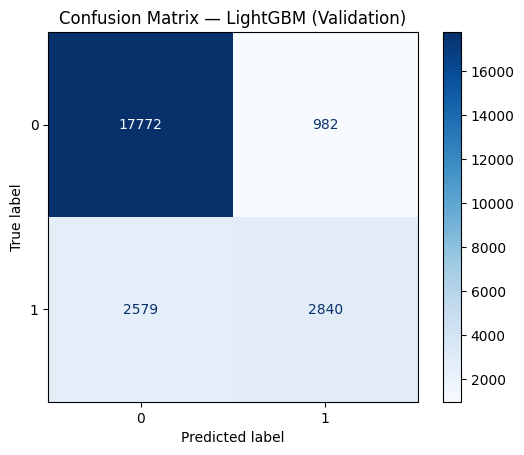

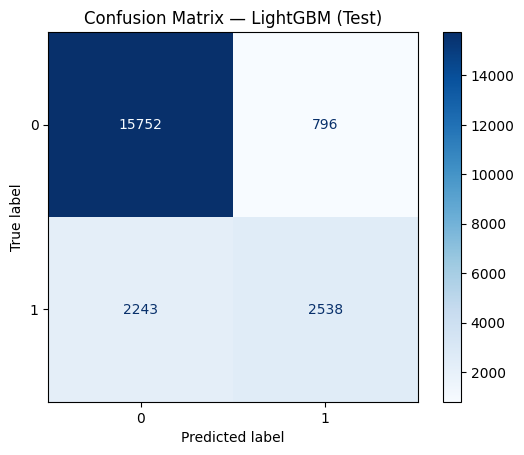

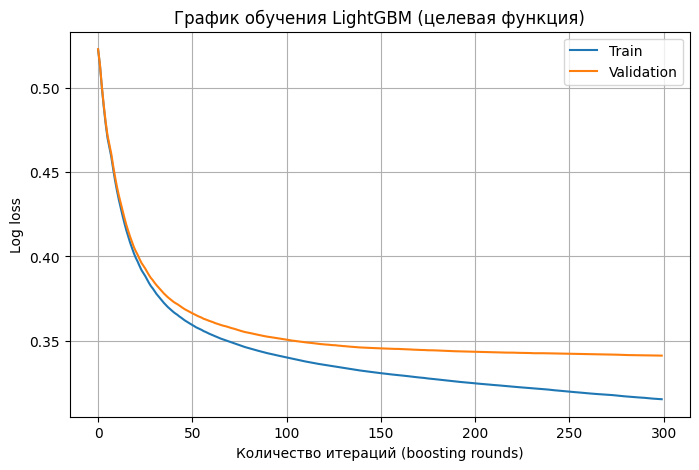

In [ ]:
# Инициализация модели LightGBM
lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    metric="binary_logloss"
)

# Обучение с мониторингом метрики на train и validation
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_metric="logloss"
)

# Предсказания
y_val_pred_lgb = lgb_model.predict(X_val)
y_test_pred_lgb = lgb_model.predict(X_test)

# Метрики
val_acc_lgb = accuracy_score(y_val, y_val_pred_lgb)
val_f1_lgb = f1_score(y_val, y_val_pred_lgb)
test_acc_lgb = accuracy_score(y_test, y_test_pred_lgb)
test_f1_lgb = f1_score(y_test, y_test_pred_lgb)

print(f"Validation Accuracy (LightGBM): {val_acc_lgb}")
print(f"Validation F1-score (LightGBM): {val_f1_lgb}")
print("\nClassification report (validation):\n", classification_report(y_val, y_val_pred_lgb))

print(f"\nTest Accuracy (LightGBM): {test_acc_lgb}")
print(f"Test F1-score (LightGBM): {test_f1_lgb}")
print("\nClassification report (test):\n", classification_report(y_test, y_test_pred_lgb))

# Матрицы ошибок
ConfusionMatrixDisplay.from_estimator(lgb_model, X_val, y_val, cmap="Blues")
plt.title("Confusion Matrix — LightGBM (Validation)")
plt.show()
ConfusionMatrixDisplay.from_estimator(lgb_model, X_test, y_test, cmap="Blues")
plt.title("Confusion Matrix — LightGBM (Test)")
plt.show()

# Получаем историю обучения
evals_result = lgb_model.evals_result_

# Строим график изменения logloss
plt.figure(figsize=(8, 5))
plt.plot(evals_result['training']['binary_logloss'], label='Train')
plt.plot(evals_result['valid_1']['binary_logloss'], label='Validation')
plt.xlabel('Количество итераций (boosting rounds)')
plt.ylabel('Log loss')
plt.title('График обучения LightGBM (целевая функция)')
plt.legend()
plt.grid(True)
plt.show()

LightGBM показал схожие результаты с XGBoost по качеству классификации.
На валидационной выборке: Accuracy: 0.8527, F1-score: 0.6147. На тестовой выборке: Accuracy: 0.8575, F1-score: 0.6255.

Как и в предыдущем методе, модель лучше классифицирует класс 0, который является доминирующим в данных. Модели работают примерно одинаково, LightGBM немного лучше обобщает на тесте, вероятно из-за более агрессивной регуляризации.

На кривых logloss видно, что обе плавно уменьшаются и разрыв между train и validation небольшой. Модель уверенно обучается и сохраняет хорошую способность к обобщению.

LightGBM подтвердил свою эффективность на табличных данных: высокая точность, хорошее обобщение на тесте, быстрое и стабильное обучение.

## 5. Optuna

Используем Optuna для поиска наилучших гиперпараметров для всех трех моделей. Она будет искать комбинации, которые максимизируют F1-score.

### Gradient Boosting

In [ ]:
def objective_gb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 200),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        "max_depth": trial.suggest_int("max_depth", 3, 6),
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 5)
    }

    model = GradientBoostingClassifier(**params, random_state=42)
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    return f1_score(y_val, preds)

study_gb = optuna.create_study(direction="maximize")
study_gb.optimize(objective_gb, n_trials=15)

print("Best GB parameters:", study_gb.best_params)
print("Best GB F1-score:", study_gb.best_value)


[I 2025-11-03 21:27:52,259] A new study created in memory with name: no-name-cc22bdf2-21d0-4459-9565-a7f0ac0daa58
[I 2025-11-03 21:28:38,274] Trial 0 finished with value: 0.5015587978550942 and parameters: {'n_estimators': 149, 'learning_rate': 0.012417547649578024, 'max_depth': 3, 'subsample': 0.8472807560181306, 'min_samples_split': 5, 'min_samples_leaf': 1}. Best is trial 0 with value: 0.5015587978550942.
[I 2025-11-03 21:29:59,388] Trial 1 finished with value: 0.5896888689205886 and parameters: {'n_estimators': 167, 'learning_rate': 0.021782908706961916, 'max_depth': 6, 'subsample': 0.777151844178949, 'min_samples_split': 7, 'min_samples_leaf': 1}. Best is trial 1 with value: 0.5896888689205886.
[I 2025-11-03 21:30:27,055] Trial 2 finished with value: 0.5831854480922803 and parameters: {'n_estimators': 113, 'learning_rate': 0.08212638192966698, 'max_depth': 3, 'subsample': 0.8782028043059955, 'min_samples_split': 3, 'min_samples_leaf': 4}. Best is trial 1 with value: 0.589688868920

Best GB parameters: {'n_estimators': 164, 'learning_rate': 0.0981631504350229, 'max_depth': 6, 'subsample': 0.9088531675948652, 'min_samples_split': 6, 'min_samples_leaf': 1}
Best GB F1-score: 0.620223271790468


Применим найденные параметры.

Validation Accuracy (GB Optuna): 0.8536383568444131
Validation F1-score (GB Optuna): 0.620223271790468

Classification report (validation):
               precision    recall  f1-score   support

           0       0.88      0.95      0.91     18754
           1       0.74      0.53      0.62      5419

    accuracy                           0.85     24173
   macro avg       0.81      0.74      0.76     24173
weighted avg       0.85      0.85      0.84     24173


Test Accuracy (GB Optuna): 0.8568146654789254
Test F1-score (GB Optuna): 0.6257352941176471

Classification report (test):
               precision    recall  f1-score   support

           0       0.88      0.95      0.91     16548
           1       0.76      0.53      0.63      4781

    accuracy                           0.86     21329
   macro avg       0.82      0.74      0.77     21329
weighted avg       0.85      0.86      0.85     21329



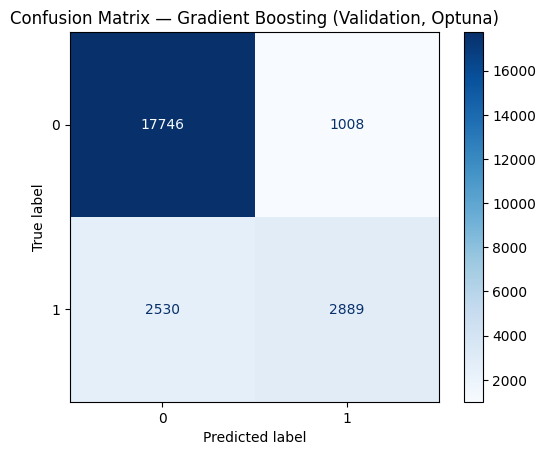

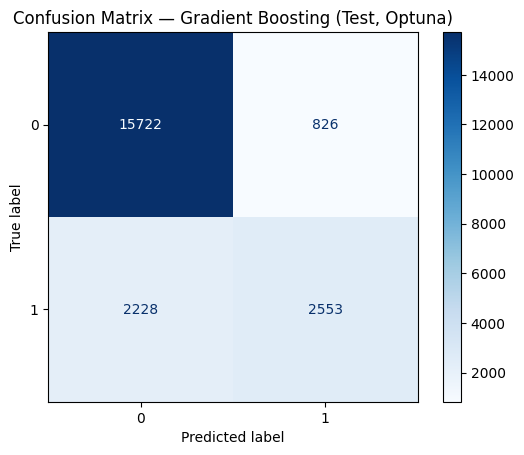

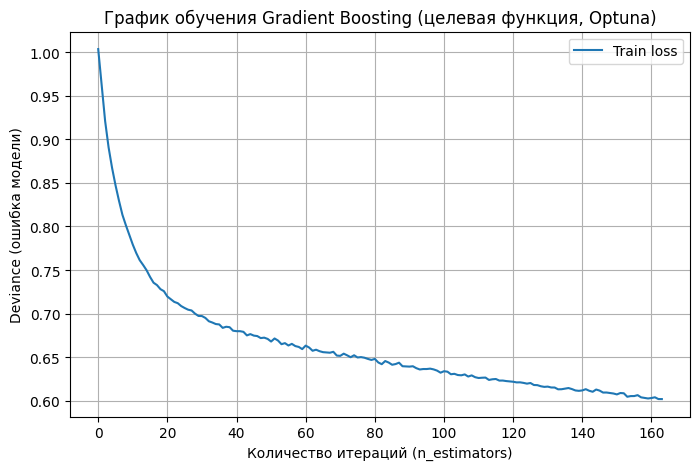

In [ ]:
# Оптимальные параметры из Optuna
best_gb_params = {
    "n_estimators": 164,
    "learning_rate": 0.0981631504350229,
    "max_depth": 6,
    "subsample": 0.9088531675948652,
    "min_samples_split": 6,
    "min_samples_leaf": 1
}

# Инициализация модели
gb_opt_model = GradientBoostingClassifier(
    **best_gb_params,
    random_state=42
)

# Обучение
gb_opt_model.fit(X_train, y_train)

# Предсказания
y_val_pred_gb_opt = gb_opt_model.predict(X_val)
y_test_pred_gb_opt = gb_opt_model.predict(X_test)

# Метрики
val_acc_gb_opt = accuracy_score(y_val, y_val_pred_gb_opt)
val_f1_gb_opt = f1_score(y_val, y_val_pred_gb_opt)

test_acc_gb_opt = accuracy_score(y_test, y_test_pred_gb_opt)
test_f1_gb_opt = f1_score(y_test, y_test_pred_gb_opt)

print(f"Validation Accuracy (GB Optuna): {val_acc_gb_opt}")
print(f"Validation F1-score (GB Optuna): {val_f1_gb_opt}")
print("\nClassification report (validation):\n", classification_report(y_val, y_val_pred_gb_opt))

print(f"\nTest Accuracy (GB Optuna): {test_acc_gb_opt}")
print(f"Test F1-score (GB Optuna): {test_f1_gb_opt}")
print("\nClassification report (test):\n", classification_report(y_test, y_test_pred_gb_opt))

# Матрицы ошибок
ConfusionMatrixDisplay.from_estimator(gb_opt_model, X_val, y_val, cmap="Blues")
plt.title("Confusion Matrix — Gradient Boosting (Validation, Optuna)")
plt.show()

ConfusionMatrixDisplay.from_estimator(gb_opt_model, X_test, y_test, cmap="Blues")
plt.title("Confusion Matrix — Gradient Boosting (Test, Optuna)")
plt.show()

# Построим график изменения функции потерь (stage-wise)
plt.figure(figsize=(8, 5))
plt.plot(gb_opt_model.train_score_, label="Train loss")
plt.xlabel("Количество итераций (n_estimators)")
plt.ylabel("Deviance (ошибка модели)")
plt.title("График обучения Gradient Boosting (целевая функция, Optuna)")
plt.legend()
plt.grid(True)
plt.show()

После оптимизации гиперпараметров с помощью Optuna качество модели заметно улучшилось по сравнению с базовой версией Gradient Boosting. Validation Accuracy выросла с 0.8452 до 0.8536, Validation F1-score с 0.5856 до 0.6202. На тестовой выборке F1-score также улучшился: с 0.5921 до 0.6257. Модель стала более сбалансированной и лучше обобщает данные без переобучения, что подтверждается близкими результатами на validation и test выборках.

На графике обучения целевой функции наблюдаются небольшие колебания, связанные с тем, что Optuna подобрала параметры, близкие к оптимальному балансу между скоростью обучения и числом деревьев. В отличие от исходной модели, где график был более плавным, здесь алгоритм обучается чуть активнее, что помогает лучше подстроиться под сложные закономерности данных.

### XGBoost

In [ ]:
def objective_xgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 200),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        "max_depth": trial.suggest_int("max_depth", 3, 6),
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0)
    }

    model = XGBClassifier(**params, random_state=42, use_label_encoder=False, eval_metric="logloss", n_jobs=-1, verbose=-1)
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    return f1_score(y_val, preds)

study_xgb = optuna.create_study(direction="maximize")
study_xgb.optimize(objective_xgb, n_trials=30)

print("Best XGB parameters:", study_xgb.best_params)
print("Best XGB F1-score:", study_xgb.best_value)


[I 2025-11-04 11:11:04,486] A new study created in memory with name: no-name-ce2c87d4-82bb-424a-b6dd-b469a7c96ade
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [11:11:04] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder", "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
[I 2025-11-04 11:11:07,565] Trial 0 finished with value: 0.5950049510397183 and parameters: {'n_estimators': 194, 'learning_rate': 0.08944353017804213, 'max_depth': 3, 'subsample': 0.8254181410956849, 'colsample_bytree': 0.7465130971325729}. Best is trial 0 with value: 0.5950049510397183.
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [11:11:08] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder", "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
[I 2025-11-04 11:11:13,699] Trial 1 finished with value: 0.6027065683793597 and parameters: {'n_estimators': 198, 'learning_

Best XGB parameters: {'n_estimators': 184, 'learning_rate': 0.08109418208658971, 'max_depth': 6, 'subsample': 0.769752239463383, 'colsample_bytree': 0.959914560551193}
Best XGB F1-score: 0.6202572694843801


Применим найденные параметры.

Validation Accuracy (XGBoost Optuna): 0.8546725685682373
Validation F1-score (XGBoost Optuna): 0.6202572694843801

Classification report (validation):
               precision    recall  f1-score   support

           0       0.87      0.95      0.91     18754
           1       0.75      0.53      0.62      5419

    accuracy                           0.85     24173
   macro avg       0.81      0.74      0.77     24173
weighted avg       0.85      0.85      0.85     24173


Test Accuracy (XGBoost Optuna): 0.8578930095175582
Test F1-score (XGBoost Optuna): 0.6264020707506471

Classification report (test):
               precision    recall  f1-score   support

           0       0.88      0.95      0.91     16548
           1       0.76      0.53      0.63      4781

    accuracy                           0.86     21329
   macro avg       0.82      0.74      0.77     21329
weighted avg       0.85      0.86      0.85     21329



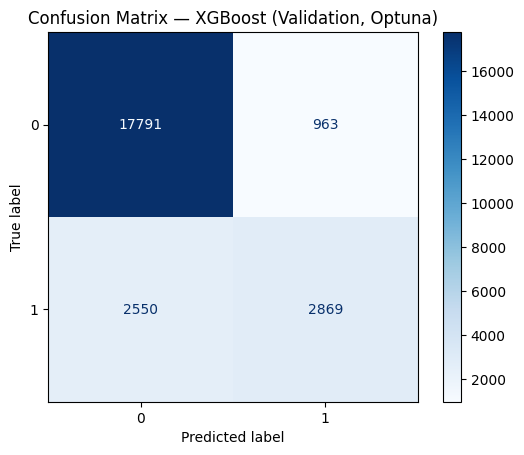

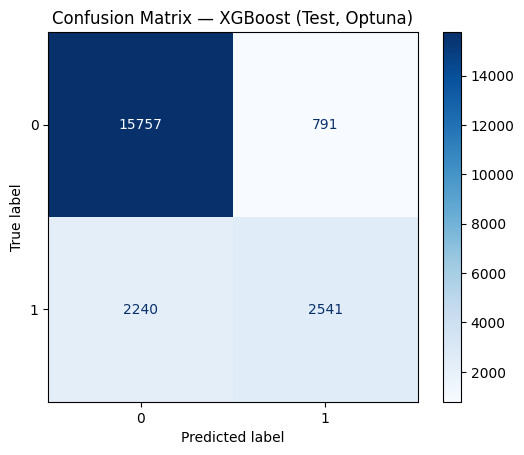

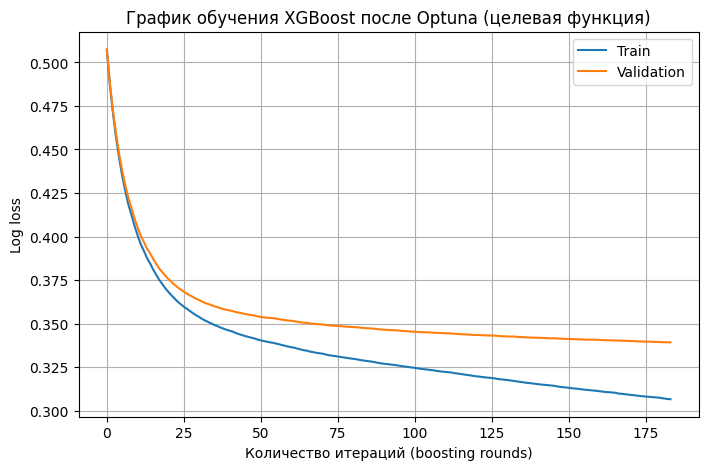

In [ ]:
best_params_xgb = {
    "n_estimators": 184,
    "learning_rate": 0.08109418208658971,
    "max_depth": 6,
    "subsample": 0.769752239463383,
    "colsample_bytree": 0.959914560551193,
    "random_state": 42,
    "n_jobs": -1,
    "eval_metric": "logloss"
}

xgb_optuna = XGBClassifier(**best_params_xgb)

# Обучаем
xgb_optuna.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False
)

y_val_pred_xgb_opt = xgb_optuna.predict(X_val)
y_test_pred_xgb_opt = xgb_optuna.predict(X_test)

# Метрики
val_acc_xgb_opt = accuracy_score(y_val, y_val_pred_xgb_opt)
val_f1_xgb_opt = f1_score(y_val, y_val_pred_xgb_opt)
test_acc_xgb_opt = accuracy_score(y_test, y_test_pred_xgb_opt)
test_f1_xgb_opt = f1_score(y_test, y_test_pred_xgb_opt)

print(f"Validation Accuracy (XGBoost Optuna): {val_acc_xgb_opt}")
print(f"Validation F1-score (XGBoost Optuna): {val_f1_xgb_opt}")
print("\nClassification report (validation):\n", classification_report(y_val, y_val_pred_xgb_opt))

print(f"\nTest Accuracy (XGBoost Optuna): {test_acc_xgb_opt}")
print(f"Test F1-score (XGBoost Optuna): {test_f1_xgb_opt}")
print("\nClassification report (test):\n", classification_report(y_test, y_test_pred_xgb_opt))

# Матрицы ошибок
ConfusionMatrixDisplay.from_estimator(xgb_optuna, X_val, y_val, cmap="Blues")
plt.title("Confusion Matrix — XGBoost (Validation, Optuna)")
plt.show()
ConfusionMatrixDisplay.from_estimator(xgb_optuna, X_test, y_test, cmap="Blues")
plt.title("Confusion Matrix — XGBoost (Test, Optuna)")
plt.show()

# График изменения целевой функции
evals_result = xgb_optuna.evals_result()

plt.figure(figsize=(8, 5))
plt.plot(evals_result['validation_0']['logloss'], label='Train')
plt.plot(evals_result['validation_1']['logloss'], label='Validation')
plt.xlabel('Количество итераций (boosting rounds)')
plt.ylabel('Log loss')
plt.title('График обучения XGBoost после Optuna (целевая функция)')
plt.legend()
plt.grid(True)
plt.show()

Оптимизация гиперпараметров с помощью Optuna дала небольшое, но стабильное улучшение всех метрик. Recall для класса 1 остался примерно на том же уровне (0.53), но precision немного вырос — модель стала чуть осторожнее при отнесении примеров к положительному классу, что и дало небольшой прирост F1.

Если на графике видно, что кривая train logloss плавно снижается, кривая validation logloss также убывает, но немного выше (и не расходится с train слишком сильно), значит модель обучена стабильно и не переобучается.

### LightGBM

In [ ]:
def objective_lgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 200),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        "num_leaves": trial.suggest_int("num_leaves", 20, 50),
        "max_depth": trial.suggest_int("max_depth", 3, 6),
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0)
    }

    model = lgb.LGBMClassifier(**params, random_state=42, n_jobs=-1, verbose=-1)
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    return f1_score(y_val, preds)

study_lgb = optuna.create_study(direction="maximize")
study_lgb.optimize(objective_lgb, n_trials=30)

print("Best LGB parameters:", study_lgb.best_params)
print("Best LGB F1-score:", study_lgb.best_value)

[I 2025-11-04 11:08:44,315] A new study created in memory with name: no-name-f77ae4c0-7ebb-40f1-8806-18afa5e18271
[I 2025-11-04 11:08:45,659] Trial 0 finished with value: 0.43145762711864405 and parameters: {'n_estimators': 109, 'learning_rate': 0.011635409028933653, 'num_leaves': 24, 'max_depth': 3, 'subsample': 0.9615656353738548, 'colsample_bytree': 0.7682637035377046}. Best is trial 0 with value: 0.43145762711864405.
[I 2025-11-04 11:08:53,230] Trial 1 finished with value: 0.5564572223510318 and parameters: {'n_estimators': 145, 'learning_rate': 0.022922384831487598, 'num_leaves': 43, 'max_depth': 4, 'subsample': 0.9399421820950378, 'colsample_bytree': 0.8773206256850024}. Best is trial 1 with value: 0.5564572223510318.
[I 2025-11-04 11:09:03,056] Trial 2 finished with value: 0.6097108565193672 and parameters: {'n_estimators': 172, 'learning_rate': 0.09178477458454345, 'num_leaves': 21, 'max_depth': 6, 'subsample': 0.8992188389303357, 'colsample_bytree': 0.7450093383833422}. Best i

Best LGB parameters: {'n_estimators': 198, 'learning_rate': 0.07489817340408647, 'num_leaves': 34, 'max_depth': 6, 'subsample': 0.9117625323564189, 'colsample_bytree': 0.9248209826970635}
Best LGB F1-score: 0.6149674620390455


Применим найденные параметры.

Validation Accuracy (LightGBM Optuna): 0.8531419352169776
Validation F1-score (LightGBM Optuna): 0.6149674620390455

Classification report (validation):
               precision    recall  f1-score   support

           0       0.87      0.95      0.91     18754
           1       0.75      0.52      0.61      5419

    accuracy                           0.85     24173
   macro avg       0.81      0.74      0.76     24173
weighted avg       0.84      0.85      0.84     24173


Test Accuracy (LightGBM Optuna): 0.8570490880960195
Test F1-score (LightGBM Optuna): 0.6223213179734919

Classification report (test):
               precision    recall  f1-score   support

           0       0.87      0.95      0.91     16548
           1       0.76      0.53      0.62      4781

    accuracy                           0.86     21329
   macro avg       0.82      0.74      0.77     21329
weighted avg       0.85      0.86      0.85     21329



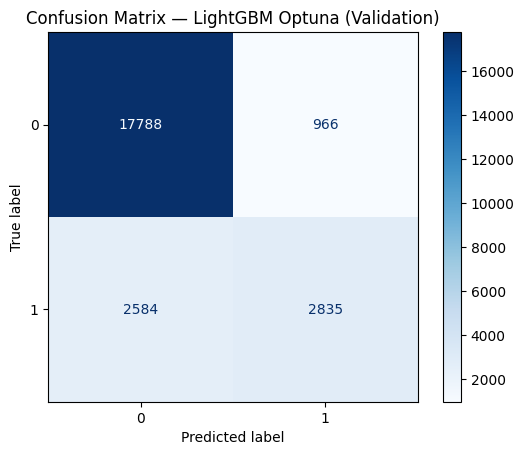

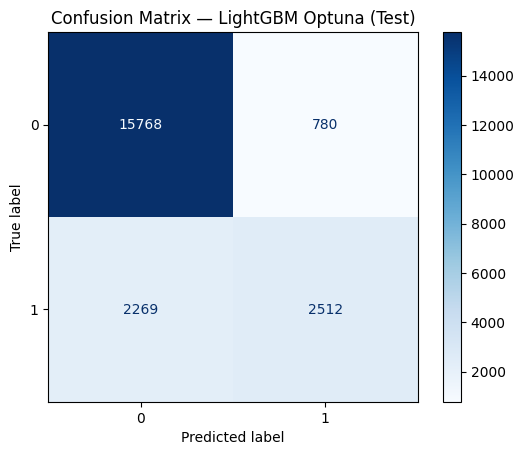

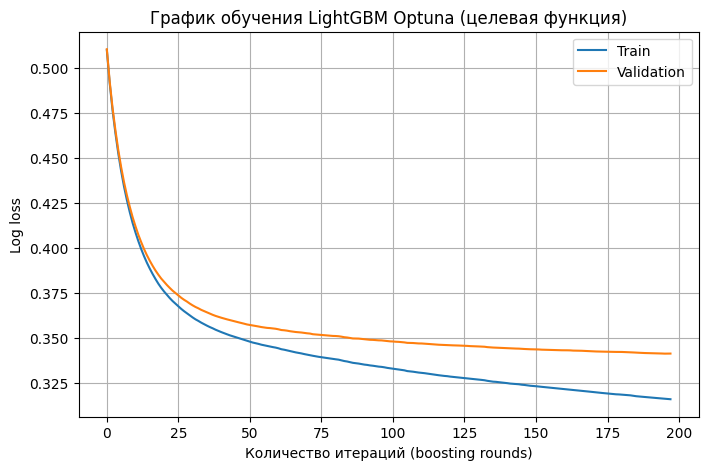

In [ ]:
# Инициализация модели LightGBM с найденными параметрами
lgb_model_optuna = lgb.LGBMClassifier(
    n_estimators=198,
    learning_rate=0.07489817340408647,
    num_leaves=34,
    max_depth=6,
    subsample=0.9117625323564189,
    colsample_bytree=0.9248209826970635,
    random_state=42,
    n_jobs=-1,
    metric="binary_logloss"
)

# Обучение модели
lgb_model_optuna.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_metric="logloss"
)

y_val_pred_lgb_optuna = lgb_model_optuna.predict(X_val)
y_test_pred_lgb_optuna = lgb_model_optuna.predict(X_test)

# Метрики
val_acc_lgb_optuna = accuracy_score(y_val, y_val_pred_lgb_optuna)
val_f1_lgb_optuna = f1_score(y_val, y_val_pred_lgb_optuna)
test_acc_lgb_optuna = accuracy_score(y_test, y_test_pred_lgb_optuna)
test_f1_lgb_optuna = f1_score(y_test, y_test_pred_lgb_optuna)

print(f"Validation Accuracy (LightGBM Optuna): {val_acc_lgb_optuna}")
print(f"Validation F1-score (LightGBM Optuna): {val_f1_lgb_optuna}")
print("\nClassification report (validation):\n", classification_report(y_val, y_val_pred_lgb_optuna))

print(f"\nTest Accuracy (LightGBM Optuna): {test_acc_lgb_optuna}")
print(f"Test F1-score (LightGBM Optuna): {test_f1_lgb_optuna}")
print("\nClassification report (test):\n", classification_report(y_test, y_test_pred_lgb_optuna))

# Матрицы ошибок
ConfusionMatrixDisplay.from_estimator(lgb_model_optuna, X_val, y_val, cmap="Blues")
plt.title("Confusion Matrix — LightGBM Optuna (Validation)")
plt.show()
ConfusionMatrixDisplay.from_estimator(lgb_model_optuna, X_test, y_test, cmap="Blues")
plt.title("Confusion Matrix — LightGBM Optuna (Test)")
plt.show()

# История обучения
evals_result_optuna = lgb_model_optuna.evals_result_

# График изменения целевой функции
plt.figure(figsize=(8, 5))
plt.plot(evals_result_optuna['training']['binary_logloss'], label='Train')
plt.plot(evals_result_optuna['valid_1']['binary_logloss'], label='Validation')
plt.xlabel('Количество итераций (boosting rounds)')
plt.ylabel('Log loss')
plt.title('График обучения LightGBM Optuna (целевая функция)')
plt.legend()
plt.grid(True)
plt.show()

Существенного роста качества не наблюдается, результаты остались практически на том же уровне, но небольшое повышение валидационной точности говорит о лёгком улучшении модели. Возможно исходные гиперпараметры уже были близки к оптимальным для данной задачи. F1-score на обоих наборах данных остался на уровне 0.61 – 0.62. Разница между Validation и Test метриками минимальна, что говорит об отсутствии переобучения.

## Вывод

В ходе работы были исследованы три модели градиентного бустинга: Gradient Boosting, XGBoost и LightGBM. Для каждой модели проведено обучение с базовыми гиперпараметрами, а затем выполнена оптимизация параметров с помощью библиотеки Optuna. Оценка производилась по метрикам Accuracy и F1-score на валидационном и тестовом наборах данных, а также по графикам изменения целевой функции.

Результаты показали, что все три модели продемонстрировали близкое качество классификации. Gradient Boosting в базовой версии показал F1-score = 0.59, который после оптимизации увеличился до 0.62, что является наиболее заметным улучшением среди всех моделей. XGBoost изначально имел F1-score = 0.618, а после настройки гиперпараметров 0.62, то есть улучшение незначительное, но стабильное. LightGBM также показал высокие результаты, F1-score на тестовых данных составил около 0.625 без оптимизации и 0.622 после неё. В целом, оптимизация с помощью Optuna позволила незначительно повысить качество моделей, в первую очередь для классического Gradient Boosting. Для XGBoost и LightGBM значимого прироста не наблюдалось, что свидетельствует о том, что их исходные настройки уже были близки к оптимальным.

По метрике Accuracy все алгоритмы продемонстрировали схожие значения — около 0.85–0.86, что говорит о высокой общей точности предсказаний. Графики изменения целевой функции у всех моделей имели схожий характер: плавное снижение без резких скачков, что подтверждает стабильность обучения.

Таким образом, наилучший баланс между скоростью обучения и качеством показали XGBoost и LightGBM, наибольшее улучшение после оптимизации у Gradient Boosting. Можно сделать вывод, что для данной задачи LightGBM является наиболее эффективным алгоритмом, обеспечивающим высокое качество предсказаний при сохранении устойчивости и скорости обучения.